# Exploring Covariance in Bivariate Gaussian Distributions

This notebook is a beginner-friendly introduction to **covariance** in **2D Gaussian (normal) distributions**.

We will learn how the **covariance matrix** changes the:

- **shape** of the data cloud,
- **orientation** of the data,
- and **spread** in different directions.

By the end of this notebook, you will be able to:

1. Generate samples from a bivariate Gaussian distribution  
2. Visualize the data with scatter plots  
3. Understand covariance matrices in simple terms  
4. Compute eigenvalues and eigenvectors  
5. See how covariance changes the principal directions of the data  
6. Understand a Gaussian as a transformed standard normal distribution  

---

## What is a bivariate Gaussian?

A **bivariate Gaussian** is a Gaussian distribution with **two variables**.

We write it as:

$$
\mathcal{N}(\mu, \Sigma)
$$

where:

- $\mu$ is the **mean vector**
- $\Sigma$ is the **covariance matrix**

For 2D data, the covariance matrix looks like:

$$
\Sigma =
\begin{bmatrix}
\sigma_1^2 & \rho\sigma_1\sigma_2 \\
\rho\sigma_1\sigma_2 & \sigma_2^2
\end{bmatrix}
$$

Here:

- $\sigma_1^2$ is the variance of the first variable
- $\sigma_2^2$ is the variance of the second variable
- $\rho$ controls how strongly the two variables move together

---

## Big intuition

- If both directions have the same variance and no covariance, the cloud looks **circular**
- If the variances are different but covariance is zero, the cloud looks like an **axis-aligned ellipse**
- If covariance is non-zero, the ellipse becomes **tilted**

## Step 1: Import libraries

We will use:

- **NumPy** for numerical calculations
- **Matplotlib** for plotting

In [1]:

import numpy as np
import matplotlib.pyplot as plt

# Make plots a little larger and easier to read
plt.rcParams["figure.figsize"] = (6, 6)
plt.rcParams["font.size"] = 12

## Step 2: Helper functions

To keep the notebook clean, we will define a few helper functions.

These functions will help us:

- generate Gaussian samples,
- draw scatter plots,
- compute eigenvalues and eigenvectors,
- and draw the principal axes of the covariance matrix.

In [2]:

def generate_samples(mean, covariance, n_samples=1000, seed=42):
    """
    Generate samples from a bivariate Gaussian distribution.

    Parameters
    ----------
    mean : array-like of shape (2,)
        Mean vector of the Gaussian.
    covariance : array-like of shape (2, 2)
        Covariance matrix.
    n_samples : int
        Number of samples to generate.
    seed : int
        Random seed for reproducibility.

    Returns
    -------
    samples : ndarray of shape (n_samples, 2)
        Generated 2D samples.
    """
    rng = np.random.default_rng(seed)
    samples = rng.multivariate_normal(mean, covariance, size=n_samples)
    return samples


def plot_samples(samples, mean, title, ax=None):
    """
    Plot 2D samples as a scatter plot and mark the mean.
    """
    if ax is None:
        fig, ax = plt.subplots()

    # Scatter plot of the points
    ax.scatter(samples[:, 0], samples[:, 1], s=12, alpha=0.5)

    # Mark the mean with a red X
    ax.scatter(mean[0], mean[1], color="red", marker="x", s=120, linewidths=3, label="Mean")

    # Label axes
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_title(title)
    ax.legend()

    # Keep the plot shape square so the geometry is easy to understand
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.3)

    return ax


def get_eigendecomposition(covariance):
    """
    Compute eigenvalues and eigenvectors of a covariance matrix.

    We use np.linalg.eigh because covariance matrices are symmetric.
    """
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)

    # Sort from largest eigenvalue to smallest
    order = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    return eigenvalues, eigenvectors


def plot_principal_axes(ax, mean, eigenvalues, eigenvectors, scale=2.5):
    """
    Draw the principal axes (eigenvectors) on top of a scatter plot.

    The direction comes from the eigenvectors.
    The length is proportional to sqrt(eigenvalue), which represents standard deviation.
    """
    for i in range(2):
        direction = eigenvectors[:, i]
        length = scale * np.sqrt(eigenvalues[i])

        # Endpoint in the positive direction
        end_pos = mean + length * direction

        # Endpoint in the negative direction
        end_neg = mean - length * direction

        # Draw the line segment for the principal axis
        ax.plot(
            [end_neg[0], end_pos[0]],
            [end_neg[1], end_pos[1]],
            linewidth=3,
            label=f"Principal axis {i+1}" if i == 0 else None
        )


def analyze_covariance(covariance, name):
    """
    Print the eigenvalues and eigenvectors of a covariance matrix.
    """
    eigenvalues, eigenvectors = get_eigendecomposition(covariance)

    print(f"--- {name} ---")
    print("Covariance matrix:")
    print(covariance)
    print("\nEigenvalues:")
    print(eigenvalues)
    print("\nEigenvectors (columns):")
    print(eigenvectors)
    print()

    return eigenvalues, eigenvectors

## Step 3: Define the mean and covariance matrices

In this notebook, we use the mean:

$$
\mu =
\begin{bmatrix}
0 \\
0
\end{bmatrix}
$$

We will study three different covariance matrices:

### 1. Isotropic
$$
\Sigma =
\begin{bmatrix}
1 & 0 \\
0 & 1
\end{bmatrix}
$$

### 2. Diagonal
$$
\Sigma =
\begin{bmatrix}
4 & 0 \\
0 & 1
\end{bmatrix}
$$

### 3. Non-zero covariance
$$
\Sigma =
\begin{bmatrix}
1 & 0.8 \\
0.8 & 1
\end{bmatrix}
$$

In [3]:

# Number of points to generate
N = 1000

# Mean vector
mean = np.array([0, 0])

# Three covariance matrices from the assignment
cov_isotropic = np.array([
    [1, 0],
    [0, 1]
])

cov_diagonal = np.array([
    [4, 0],
    [0, 1]
])

cov_nonzero = np.array([
    [1, 0.8],
    [0.8, 1]
])

covariances = {
    "Isotropic": cov_isotropic,
    "Diagonal": cov_diagonal,
    "Non-zero covariance": cov_nonzero
}

## Step 4: Generate data

Now we generate **1000 samples** for each covariance matrix.

In [4]:

# Generate one sample set for each covariance matrix
samples_dict = {}

for i, (name, cov) in enumerate(covariances.items()):
    # We change the seed slightly so each case gets its own sample
    samples = generate_samples(mean, cov, n_samples=N, seed=42 + i)
    samples_dict[name] = samples

# Check one example
samples_dict["Isotropic"][:5]

array([[ 0.30471708, -1.03998411],
       [ 0.7504512 ,  0.94056472],
       [-1.95103519, -1.30217951],
       [ 0.1278404 , -0.31624259],
       [-0.01680116, -0.85304393]])

## Step 5: Visualize the sampled data

We create a scatter plot for each case and mark the mean.

Look carefully at the **shape** of the point cloud:

- Is it circular?
- Is it stretched more in one direction?
- Is it tilted?

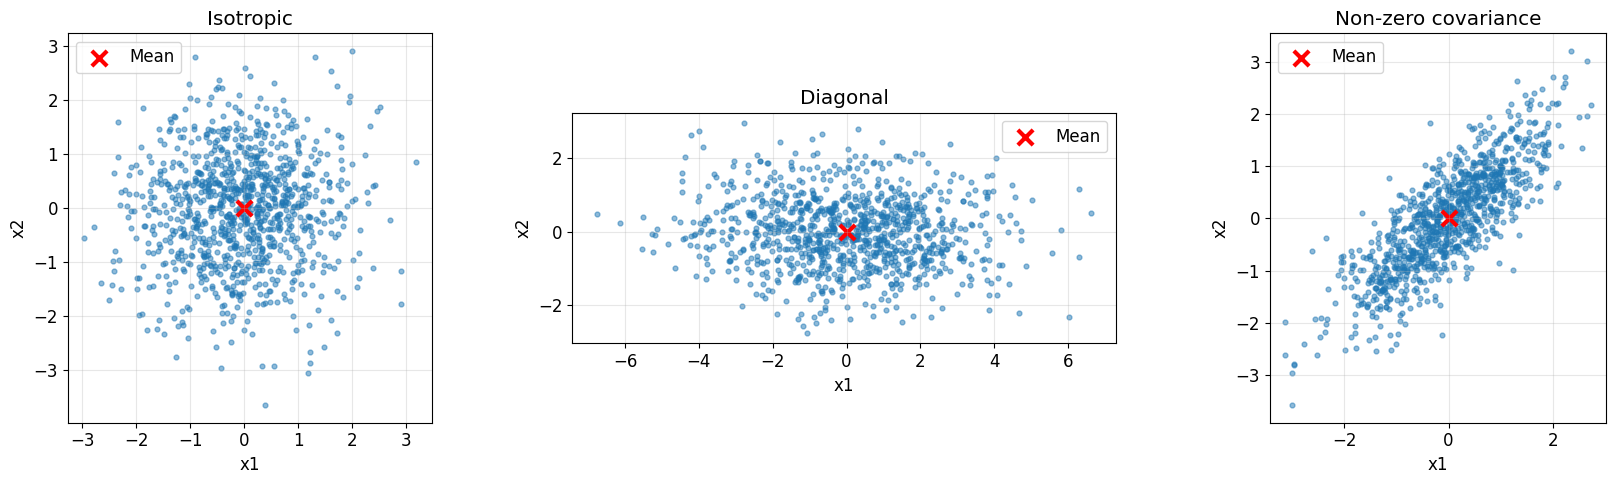

In [5]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, samples) in zip(axes, samples_dict.items()):
    plot_samples(samples, mean, name, ax=ax)

plt.tight_layout()
plt.show()

## What should you observe?

### Isotropic covariance
The data should look approximately like a **circle** around the origin.

Why?  
Because the variance is the same in every direction:

$$
\Sigma = I
$$

There is **no preferred direction**.

---

### Diagonal covariance
The data should look like an **ellipse aligned with the x- and y-axes**.

Why?  
Because the variance along the first axis is larger than the second:

- variance in $x_1$ is 4
- variance in $x_2$ is 1

But the covariance is still zero, so there is **no tilt**.

---

### Non-zero covariance
The data should look like a **tilted ellipse**.

Why?  
Because when covariance is non-zero, the variables move together, and the direction of largest spread is no longer exactly along the x- or y-axis.

## Step 6: Compute eigenvalues and eigenvectors

The **eigenvectors** tell us the important directions of the data.

The **eigenvalues** tell us how much spread there is in those directions.

This is why eigenvalues and eigenvectors are very useful for understanding covariance matrices.

In [6]:

# Analyze each covariance matrix numerically
eig_results = {}

for name, cov in covariances.items():
    eigenvalues, eigenvectors = analyze_covariance(cov, name)
    eig_results[name] = (eigenvalues, eigenvectors)

--- Isotropic ---
Covariance matrix:
[[1 0]
 [0 1]]

Eigenvalues:
[1. 1.]

Eigenvectors (columns):
[[0. 1.]
 [1. 0.]]

--- Diagonal ---
Covariance matrix:
[[4 0]
 [0 1]]

Eigenvalues:
[4. 1.]

Eigenvectors (columns):
[[1. 0.]
 [0. 1.]]

--- Non-zero covariance ---
Covariance matrix:
[[1.  0.8]
 [0.8 1. ]]

Eigenvalues:
[1.8 0.2]

Eigenvectors (columns):
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]



## Step 7: Plot the principal axes

We now draw the principal axes on top of the sampled points.

These axes come from the **eigenvectors** of the covariance matrix.

The length of each axis is based on:

$$
\sqrt{\lambda}
$$

where $\lambda$ is an eigenvalue.

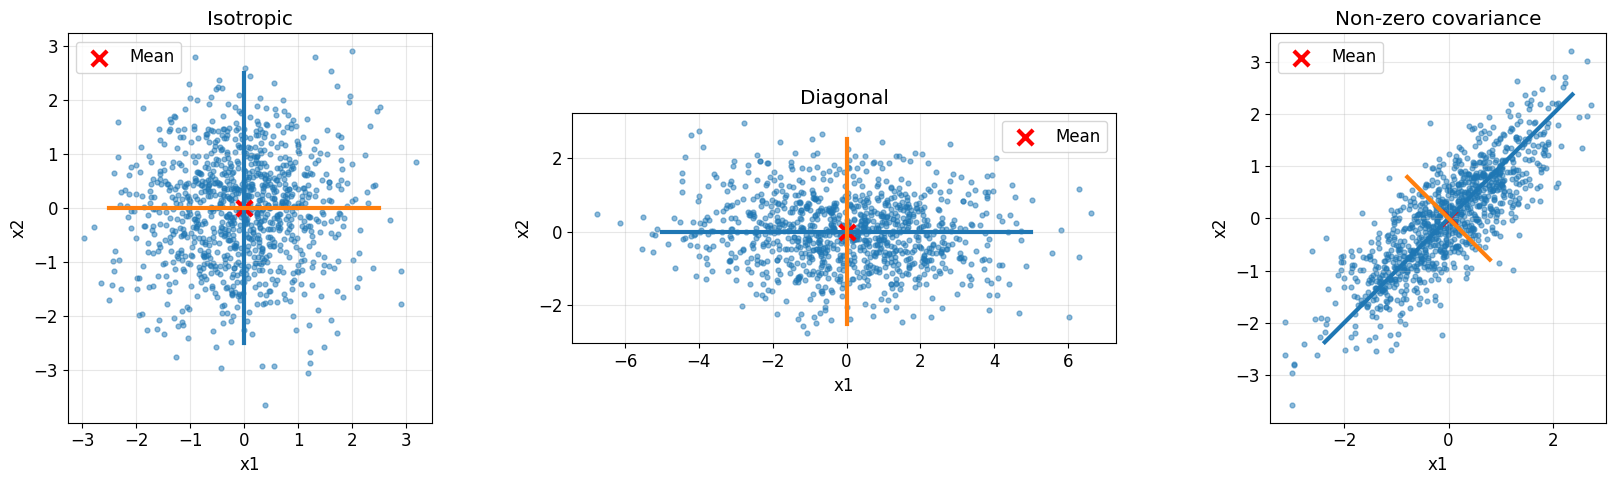

In [7]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, samples) in zip(axes, samples_dict.items()):
    # Scatter plot
    plot_samples(samples, mean, name, ax=ax)

    # Get eigen information for this covariance matrix
    eigenvalues, eigenvectors = eig_results[name]

    # Draw principal axes
    plot_principal_axes(ax, mean, eigenvalues, eigenvectors)

plt.tight_layout()
plt.show()

## Step 8: Interpret the results

Let us interpret each case in simple language.

### 1. Isotropic covariance
- **Shape:** circular
- **Orientation:** no special orientation
- **Spread:** equal in every direction

Why does isotropic covariance produce a circle?

Because the covariance matrix is the identity matrix:

$$
\Sigma =
\begin{bmatrix}
1 & 0 \\
0 & 1
\end{bmatrix}
$$

This means:
- same variance in both directions
- zero covariance
- no direction is special

So the data spreads equally in all directions.

---

### 2. Diagonal covariance
- **Shape:** elliptical
- **Orientation:** aligned with the x- and y-axes
- **Spread:** more along the first axis than the second

Why does diagonal covariance produce an axis-aligned ellipse?

Because the covariance matrix is diagonal:

$$
\Sigma =
\begin{bmatrix}
4 & 0 \\
0 & 1
\end{bmatrix}
$$

This means:
- no covariance between variables
- the axes remain aligned with the coordinate axes
- but the variances are different, so one axis is stretched more

---

### 3. Non-zero covariance
- **Shape:** elliptical
- **Orientation:** tilted
- **Spread:** largest along a rotated direction

How does non-zero covariance affect orientation?

A non-zero covariance means the two variables change together.
That creates a rotated direction where the data has maximum spread.

So the ellipse is no longer aligned with the x- and y-axes.

## Step 9: Correlation study

Now we vary the correlation value:

$$
\rho \in \{-0.9, -0.5, 0, 0.5, 0.9\}
$$

For each value, we use the covariance matrix:

$$
\Sigma =
\begin{bmatrix}
1 & \rho \\
\rho & 1
\end{bmatrix}
$$

Since both variances are 1, changing $\rho$ mainly changes the **orientation** and the **strength of the tilt**.

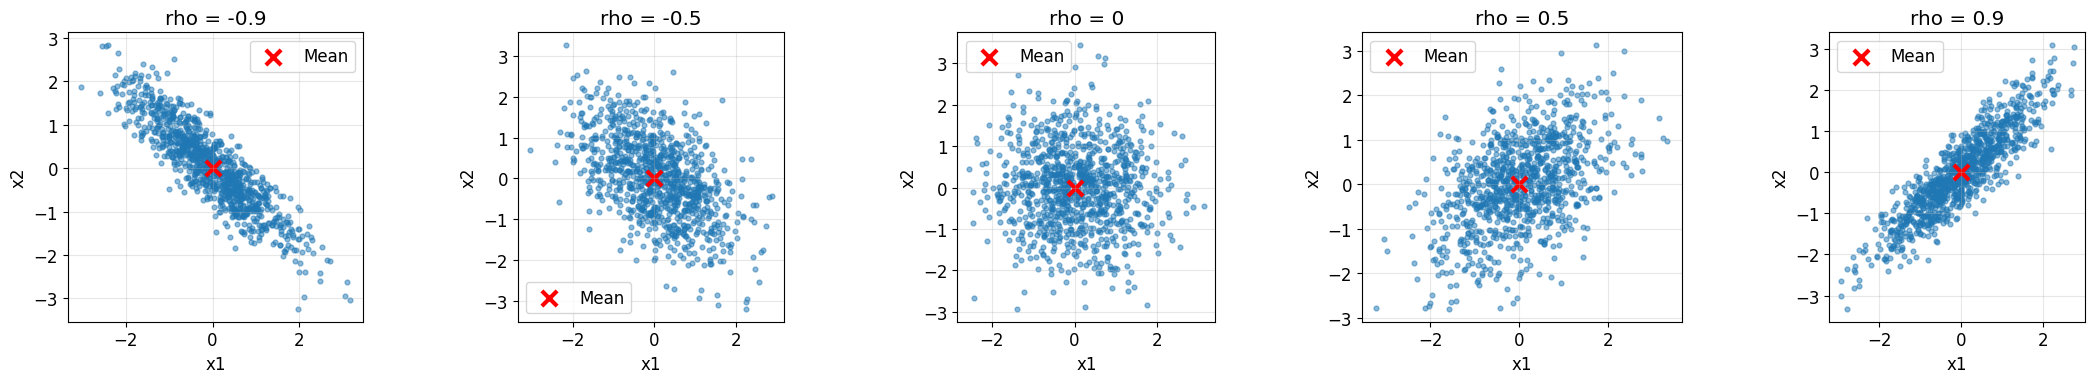

In [8]:

rho_values = [-0.9, -0.5, 0, 0.5, 0.9]

fig, axes = plt.subplots(1, len(rho_values), figsize=(22, 4))

for ax, rho in zip(axes, rho_values):
    # Build the covariance matrix for this rho
    cov_rho = np.array([
        [1, rho],
        [rho, 1]
    ])

    # Generate data
    samples = generate_samples(mean, cov_rho, n_samples=N, seed=int((rho + 1) * 100))

    # Plot the data
    plot_samples(samples, mean, f"rho = {rho}", ax=ax)

plt.tight_layout()
plt.show()

## What should you notice when $\rho$ changes?

### When $\rho > 0$
The cloud tilts upward from left to right.

That means:
- when one variable increases, the other tends to increase too

### When $\rho < 0$
The cloud tilts downward from left to right.

That means:
- when one variable increases, the other tends to decrease

### When $\rho = 0$
There is no linear relationship, so the cloud is not tilted.

### As $|\rho|$ gets larger
The tilt becomes stronger and the ellipse becomes more stretched along one diagonal direction.

## Optional: inspect eigenvalues and eigenvectors for each correlation

This code helps us connect the shape of the plot to the numbers.

In [9]:

for rho in rho_values:
    cov_rho = np.array([
        [1, rho],
        [rho, 1]
    ])

    eigenvalues, eigenvectors = get_eigendecomposition(cov_rho)

    print(f"rho = {rho}")
    print("Covariance matrix:")
    print(cov_rho)
    print("Eigenvalues:", eigenvalues)
    print("Eigenvectors:")
    print(eigenvectors)
    print("-" * 40)

rho = -0.9
Covariance matrix:
[[ 1.  -0.9]
 [-0.9  1. ]]
Eigenvalues: [1.9 0.1]
Eigenvectors:
[[-0.70710678 -0.70710678]
 [ 0.70710678 -0.70710678]]
----------------------------------------
rho = -0.5
Covariance matrix:
[[ 1.  -0.5]
 [-0.5  1. ]]
Eigenvalues: [1.5 0.5]
Eigenvectors:
[[-0.70710678 -0.70710678]
 [ 0.70710678 -0.70710678]]
----------------------------------------
rho = 0
Covariance matrix:
[[1 0]
 [0 1]]
Eigenvalues: [1. 1.]
Eigenvectors:
[[0. 1.]
 [1. 0.]]
----------------------------------------
rho = 0.5
Covariance matrix:
[[1.  0.5]
 [0.5 1. ]]
Eigenvalues: [1.5 0.5]
Eigenvectors:
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]
----------------------------------------
rho = 0.9
Covariance matrix:
[[1.  0.9]
 [0.9 1. ]]
Eigenvalues: [1.9 0.1]
Eigenvectors:
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]
----------------------------------------


## Step 10: Transformation view

A bivariate Gaussian can be seen as a **linear transformation** of a standard normal distribution.

Start with:

$$
z \sim \mathcal{N}(0, I)
$$

Then transform it using:

$$
x = Az
$$

If we choose $A$ correctly, then:

$$
x \sim \mathcal{N}(0, \Sigma)
$$

and

$$
\Sigma = AA^T
$$

This is a very important idea in probability, statistics, and machine learning.

### Our covariance matrix for this part

We use:

$$
\Sigma =
\begin{bmatrix}
1 & 0.8 \\
0.8 & 1
\end{bmatrix}
$$

We will:

1. generate circular standard normal data $z$
2. compute a matrix $A$ such that $\Sigma = AA^T$
3. transform the data using $x = Az$
4. compare the plots of $z$ and $x$

In [10]:

# Covariance matrix for the transformation view
Sigma = np.array([
    [1, 0.8],
    [0.8, 1]
])

# Step 1: generate standard normal points z ~ N(0, I)
rng = np.random.default_rng(123)
z = rng.standard_normal(size=(N, 2))

# Step 2: eigendecomposition of Sigma
# Sigma = Q Lambda Q^T
eigenvalues, eigenvectors = np.linalg.eigh(Sigma)

# Build Lambda^(1/2)
Lambda_sqrt = np.diag(np.sqrt(eigenvalues))

# Compute A = Q Lambda^(1/2)
A = eigenvectors @ Lambda_sqrt

# Step 3: transform z to x
# We use matrix multiplication for every point
x = z @ A.T

print("Sigma:")
print(Sigma)
print("\nMatrix A such that Sigma = A A^T:")
print(A)

Sigma:
[[1.  0.8]
 [0.8 1. ]]

Matrix A such that Sigma = A A^T:
[[-0.31622777  0.9486833 ]
 [ 0.31622777  0.9486833 ]]


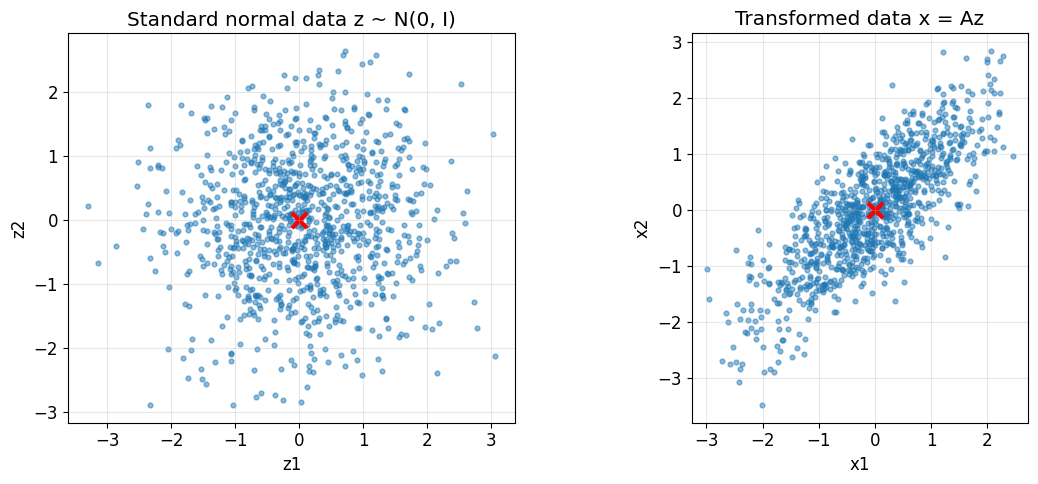

In [11]:

# Compare the original circular data and transformed elliptical data
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot z
axes[0].scatter(z[:, 0], z[:, 1], s=12, alpha=0.5)
axes[0].scatter(0, 0, color="red", marker="x", s=120, linewidths=3)
axes[0].set_title("Standard normal data z ~ N(0, I)")
axes[0].set_xlabel("z1")
axes[0].set_ylabel("z2")
axes[0].set_aspect("equal", adjustable="box")
axes[0].grid(True, alpha=0.3)

# Plot x
axes[1].scatter(x[:, 0], x[:, 1], s=12, alpha=0.5)
axes[1].scatter(0, 0, color="red", marker="x", s=120, linewidths=3)
axes[1].set_title("Transformed data x = Az")
axes[1].set_xlabel("x1")
axes[1].set_ylabel("x2")
axes[1].set_aspect("equal", adjustable="box")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Check that $\Sigma = AA^T$

This is a good habit when working with transformations.

In [12]:

# Verify that A A^T gives back Sigma
Sigma_reconstructed = A @ A.T

print("Original Sigma:")
print(Sigma)

print("\nReconstructed Sigma = A @ A.T:")
print(Sigma_reconstructed)

print("\nAre they close?")
print(np.allclose(Sigma, Sigma_reconstructed))

Original Sigma:
[[1.  0.8]
 [0.8 1. ]]

Reconstructed Sigma = A @ A.T:
[[1.  0.8]
 [0.8 1. ]]

Are they close?
True


## Interpretation of the transformation view

This section gives a very powerful geometric interpretation:

- The standard normal distribution starts as a **circle-like cloud**
- The matrix $A$ **stretches** and **rotates** that cloud
- The result is an **ellipse-like cloud**
- The covariance matrix tells us exactly how this stretching happens

### Important ideas
- **Eigenvectors** give the directions of stretch
- **Eigenvalues** give how much stretching happens
- The transformation matrix $A$ turns a circular cloud into an elliptical one

# Summary

In this notebook, you learned that:

- A covariance matrix controls the **shape**, **spread**, and **orientation** of a Gaussian distribution
- Equal variance in all directions produces a **circular** cloud
- Different variances with zero covariance produce an **axis-aligned ellipse**
- Non-zero covariance produces a **tilted ellipse**
- Eigenvalues and eigenvectors help explain the principal directions of spread
- A correlated Gaussian can be created by transforming standard normal data

# Exercises

Try these on your own before looking up the answer.

---

## Exercise 1: A stretched axis-aligned Gaussian

Use the covariance matrix:

$$
\Sigma =
\begin{bmatrix}
9 & 0 \\
0 & 1
\end{bmatrix}
$$

### Tasks
1. Generate 1000 samples
2. Plot the data
3. Compute eigenvalues and eigenvectors
4. Explain:
   - Why is the ellipse axis-aligned?
   - Why is the spread much larger in one direction?

Write your answer in words below the plot.

In [ ]:

# Exercise 1 starter code

# TODO: define the covariance matrix
cov_ex1 = np.array([
    [9, 0],
    [0, 1]
])

# TODO: generate samples
samples_ex1 = generate_samples(mean, cov_ex1, n_samples=1000, seed=202)

# TODO: plot the samples
fig, ax = plt.subplots()
plot_samples(samples_ex1, mean, "Exercise 1: Axis-aligned ellipse", ax=ax)

# TODO: compute eigenvalues and eigenvectors
eigenvalues_ex1, eigenvectors_ex1 = get_eigendecomposition(cov_ex1)

# TODO: plot principal axes
plot_principal_axes(ax, mean, eigenvalues_ex1, eigenvectors_ex1)

plt.show()

print("Eigenvalues:", eigenvalues_ex1)
print("Eigenvectors:")
print(eigenvectors_ex1)

# Write your explanation in a markdown cell below this code cell.

## Exercise 2: Negative correlation

Use the covariance matrix:

$$
\Sigma =
\begin{bmatrix}
1 & -0.7 \\
-0.7 & 1
\end{bmatrix}
$$

### Tasks
1. Generate 1000 samples
2. Plot the data
3. Compute eigenvalues and eigenvectors
4. Compare it with the case $\rho = +0.7$
5. Explain how the sign of covariance changes the orientation

In [ ]:

# Exercise 2 starter code

# TODO: define the covariance matrix
cov_ex2 = np.array([
    [1, -0.7],
    [-0.7, 1]
])

# TODO: generate samples
samples_ex2 = generate_samples(mean, cov_ex2, n_samples=1000, seed=303)

# TODO: plot the samples
fig, ax = plt.subplots()
plot_samples(samples_ex2, mean, "Exercise 2: Negative correlation", ax=ax)

# TODO: compute eigenvalues and eigenvectors
eigenvalues_ex2, eigenvectors_ex2 = get_eigendecomposition(cov_ex2)

# TODO: plot principal axes
plot_principal_axes(ax, mean, eigenvalues_ex2, eigenvectors_ex2)

plt.show()

print("Eigenvalues:", eigenvalues_ex2)
print("Eigenvectors:")
print(eigenvectors_ex2)

# Question:
# How is this plot different from the positive-correlation case?

## Final note for students

When you study covariance, always ask:

1. Is the cloud **circular** or **elliptical**?
2. Is it **axis-aligned** or **tilted**?
3. Which direction has the **largest spread**?
4. What do the **eigenvalues** and **eigenvectors** say?

These questions will help you understand many future topics such as:

- PCA (Principal Component Analysis)
- Gaussian distributions
- linear transformations
- multivariate statistics
- machine learning